In [1]:

import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv("/content/marketing_sample_for_naukri_com-jobs__20190701_20190830__30k_data.csv")
print("Shape:", df.shape)
df.head(3)


Shape: (30000, 11)


,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.drop_duplicates(inplace  = True)

In [5]:
# 3. Drop Missing Target / Feature Rows

df = df.dropna(subset=["Role Category", "Job Title", "Key Skills"])

In [6]:
# Keep only the top 15 most frequent Role Categories (rest are too rare to model)
top_categories = df["Role Category"].value_counts().head(15).index
df = df[df["Role Category"].isin(top_categories)].copy()
print("Shape after filtering to top 15 categories:", df.shape)

Shape after filtering to top 15 categories: (20973, 11)


In [7]:
# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s|]", " ", text)     # keep only letters, spaces, pipes
    text = re.sub(r"\s+", " ", text).strip()   # collapse whitespace
    return text

In [9]:
df["combined_text"] = (
    df["Job Title"].fillna("") + " " +
    df["Key Skills"].fillna("") + " " +
    df["Location"].fillna("")
)
df["clean_text"] = df["combined_text"].apply(clean_text)


In [10]:
# Encode Labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Role Category"])
num_classes = df["label"].nunique()


In [11]:
# Train / Test Split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)


In [12]:
MAX_LEN = 40

In [13]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

In [14]:

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [15]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [16]:
y_train_arr = y_train.values
y_test_arr = y_test.values

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
rnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, mask_zero=True),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])


In [19]:
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [21]:
history = rnn_model.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.4667 - loss: 1.8412 - val_accuracy: 0.5983 - val_loss: 1.4163
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6194 - loss: 1.2871 - val_accuracy: 0.6424 - val_loss: 1.1686
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6619 - loss: 1.0857 - val_accuracy: 0.6710 - val_loss: 1.0906
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7186 - loss: 0.9292 - val_accuracy: 0.7163 - val_loss: 1.0061
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7592 - loss: 0.8077 - val_accuracy: 0.7360 - val_loss: 0.9186
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7815 - loss: 0.7250 - val_accuracy: 0.7372 - val_loss: 0.9521
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8042 - loss: 0.6492 - val_accuracy: 0.7449 - val_loss: 0.9076
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8208 - loss: 0.5940 - val_acc

In [23]:
start = time.time()
print(f"Training time: {time.time() - start:.2f}s")

Training time: 0.00s


In [24]:
# Evaluate


In [25]:
y_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)

print(classification_report(y_test_arr, y_pred, target_names=label_encoder.classes_))
print("Accuracy:", accuracy_score(y_test_arr, y_pred))

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
                                            precision    recall  f1-score   support

                                  Accounts       0.71      0.90      0.79       172
Admin/Maintenance/Security/Datawarehousing       0.41      0.52      0.46       182
                           Corporate Sales       0.17      0.01      0.01       139
                                  Creative       0.66      0.51      0.58        78
                        Engineering Design       0.71      0.41      0.52        71
                      HR/ Recruitment / IR       0.76      0.80      0.78       220
                                 Marketing       0.41      0.57      0.48        93
                      Medical Professional       0.77      0.61      0.68        82
                                     Other       0.14      0.05      0.07       170
      Production/Manufacturing/Maintenance       0.67      0.68      0.67       114
                      Programming

In [26]:
cm = confusion_matrix(y_test_arr, y_pred)

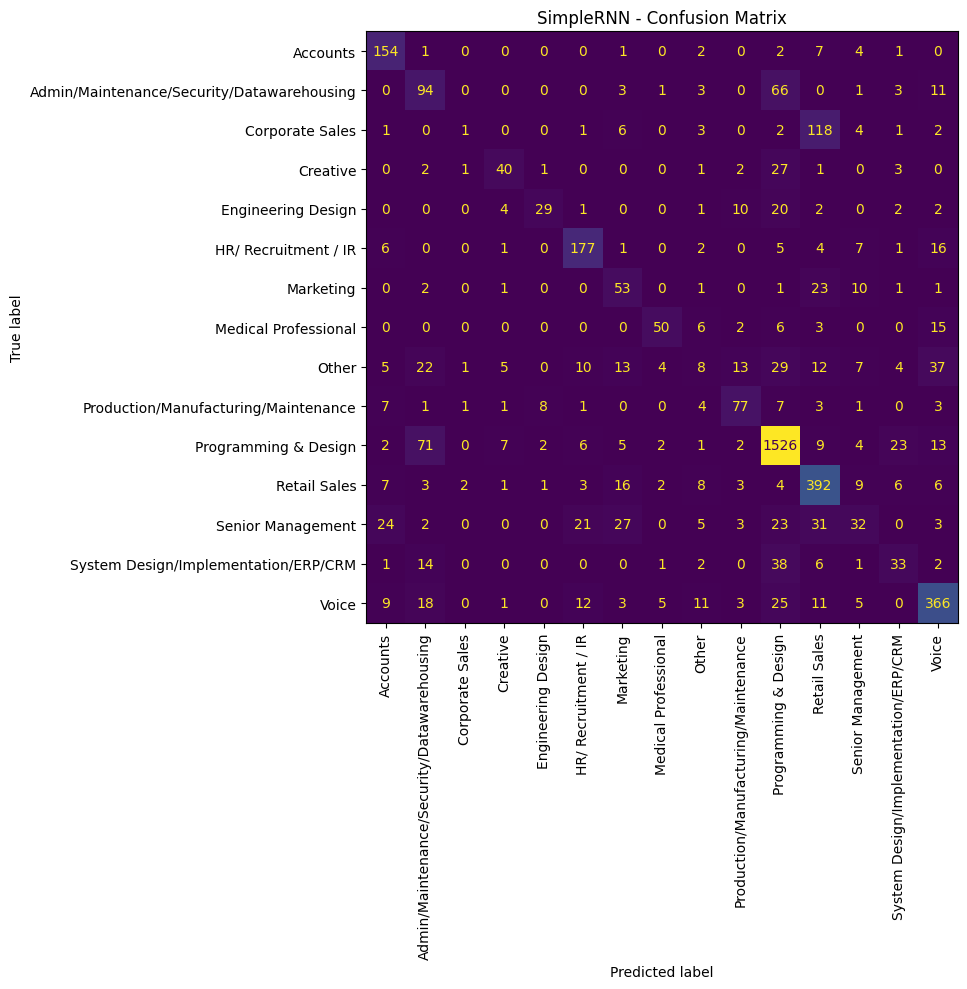

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("SimpleRNN - Confusion Matrix")
plt.tight_layout()
plt.savefig("simplernn_confusion_matrix.png")
plt.show()

In [28]:
rnn_model.save("simplernn_role_model.h5")

In [29]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [30]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [31]:
print("Saved: simplernn_role_model.h5, tokenizer.pkl, label_encoder.pkl")

Saved: simplernn_role_model.h5, tokenizer.pkl, label_encoder.pkl
